# Comparison & Analysis — 4 Versioni a Confronto
## Plant Disease Detection — V1 (HOG+SVM) · V2 (Custom CNN) · V3 (ResNet50 TL) · V4 (DINOv3 SSL)

Carica le metriche di tutte le versioni, le confronta su accuracy/precision/recall/F1, mostra i trade-off tempo/parametri, e produce la tabella riassuntiva per il documento tecnico.

In [1]:
# ── Cella 1: Load tutti i metrics JSON ─────────────────────────
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
METRICS_DIR  = PROJECT_ROOT / "results" / "metrics"
PLOTS_DIR    = PROJECT_ROOT / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def load_metrics(path: Path) -> dict:
    """Normalizza le 4 versioni in un dict unico.
       V1 ha le metriche nested in 'test', le altre versioni le hanno top-level."""
    d = json.loads(path.read_text())
    if "test" in d:  # formato V1
        return {
            "model":     "V1_HOG_SVM",
            "accuracy":  d["test"]["accuracy"],
            "precision": d["test"]["precision"],
            "recall":    d["test"]["recall"],
            "f1":        d["test"]["f1"],
            "training_time_min": d["config"]["train_time_s"] / 60,
            "inference_ms":      d["test"]["inference_ms_per_image"],
            "raw": d,
        }
    # V2, V3, V4 hanno già il formato canonico (top-level metrics)
    return {**d, "raw": d}


metrics = {
    "V1": load_metrics(METRICS_DIR / "v1_metrics.json"),
    "V2": load_metrics(METRICS_DIR / "v2_metrics.json"),
    "V3": load_metrics(METRICS_DIR / "v3_metrics.json"),
    "V4": load_metrics(METRICS_DIR / "v4_metrics.json"),
}

# DataFrame metriche principali (righe = metriche, colonne = versioni)
rows = ["accuracy", "precision", "recall", "f1"]
df_metrics = pd.DataFrame(
    {ver: [round(m[r], 4) for r in rows] for ver, m in metrics.items()},
    index=[r.capitalize() for r in rows],
)
df_metrics.to_csv(METRICS_DIR / "comparison_table.csv")
print("── Tabella metriche (test set) ──")
print(df_metrics.to_string())
print(f"\nSalvato: {METRICS_DIR/'comparison_table.csv'} ✅")

── Tabella metriche (test set) ──
               V1      V2      V3      V4
Accuracy   0.7439  0.9966  0.9987  0.9835
Precision  0.7462  0.9966  0.9988  0.9839
Recall     0.7439  0.9966  0.9987  0.9835
F1         0.7426  0.9966  0.9987  0.9835

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/metrics/comparison_table.csv ✅


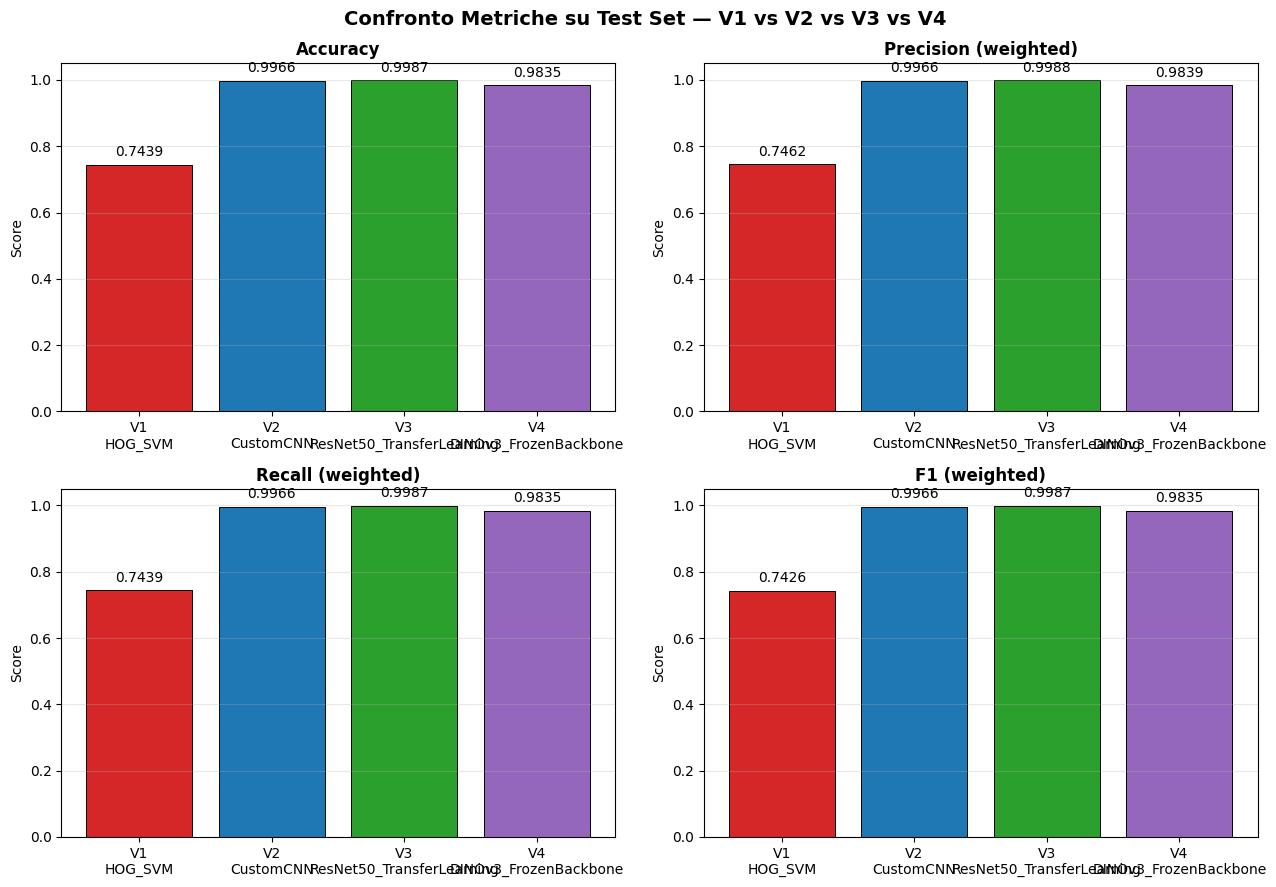

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/plots/metrics_comparison.png ✅


In [2]:
# ── Cella 2: Bar chart 2x2 — Accuracy / Precision / Recall / F1 ──────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_names = ["accuracy", "precision", "recall", "f1"]
titles       = ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"]
colors       = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd"]  # V1, V2, V3, V4
versions     = list(metrics.keys())
labels       = [f"{v}\n{metrics[v].get('model', '?').split('_',1)[-1]}" for v in versions]

for ax, key, title in zip(axes.flat, metric_names, titles):
    vals = [metrics[v][key] for v in versions]
    bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.annotate(f"{v:.4f}",
                    xy=(bar.get_x() + bar.get_width()/2, v),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)
plt.suptitle("Confronto Metriche su Test Set — V1 vs V2 vs V3 vs V4",
             fontsize=14, fontweight="bold")
plt.tight_layout()
out_path = PLOTS_DIR / "metrics_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_path} ✅")

── Trade-off ──
version                            approach  accuracy       f1  training_time_min  trainable_params
     V1                    Shallow Learning  0.743945 0.742599              25.24               NaN
     V2             Custom CNN from scratch  0.996600 0.996600             294.14          661574.0
     V3       Transfer Learning (fine-tune)  0.998700 0.998700             127.81        16033318.0
     V4 SSL Foundation Model + Linear Probe  0.983500 0.983500              12.49               0.0


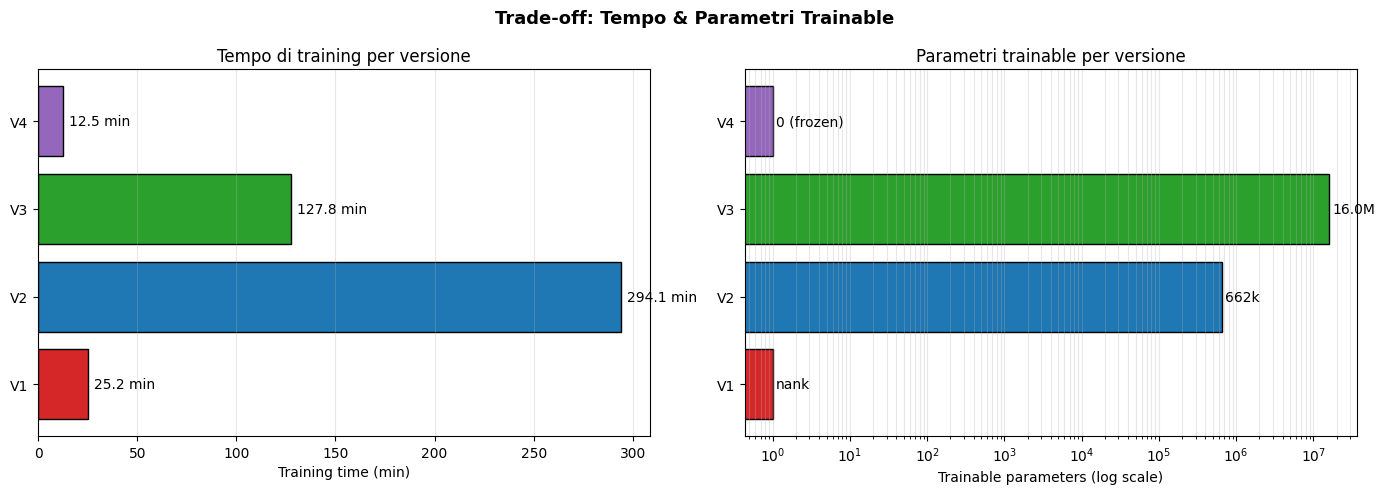

Salvato: /Users/marco/Documents/repos/ComputerVisionProject/results/plots/tradeoff_time_params.png ✅


In [3]:
# ── Cella 3: Trade-off plots — Accuracy vs Training Time vs Trainable Params ──
# Costruisce due plot orizzontali: tempo di training e parametri trainable

def safe(d, key, default=None):
    return d.get(key, default) if isinstance(d, dict) else default

rows = []
for ver, m in metrics.items():
    raw = m["raw"]
    if ver == "V1":
        trainable = None  # SVM: support vectors, non comparabile con NN params
        approach  = "Shallow Learning"
        ttime     = m["training_time_min"]
    elif ver == "V2":
        trainable = 661574  # da Cella 3 del notebook 02 (~0.7M)
        approach  = "Custom CNN from scratch"
        ttime     = m["training_time_min"]
    elif ver == "V3":
        trainable = raw.get("trainable_params")
        approach  = "Transfer Learning (fine-tune)"
        ttime     = m["training_time_min"]
    else:  # V4
        trainable = 0  # backbone congelato, head è solo logistic regression
        approach  = "SSL Foundation Model + Linear Probe"
        ttime     = raw.get("extract_time_min", 0)
    rows.append({
        "version": ver,
        "approach": approach,
        "accuracy": m["accuracy"],
        "f1": m["f1"],
        "training_time_min": round(ttime, 2),
        "trainable_params": trainable,
    })
df_trade = pd.DataFrame(rows)
print("── Trade-off ──")
print(df_trade.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
vers = df_trade["version"].tolist()
cols = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd"]

# Plot 1: training time
ax1.barh(vers, df_trade["training_time_min"], color=cols, edgecolor="black")
ax1.set_xlabel("Training time (min)")
ax1.set_title("Tempo di training per versione")
for i, v in enumerate(df_trade["training_time_min"]):
    ax1.text(v + max(df_trade['training_time_min'])*0.01, i, f"{v:.1f} min", va="center")
ax1.grid(axis="x", alpha=0.3)

# Plot 2: trainable params (log scale, V1=NA, V4=0 → mostra come 1 per la scala log)
params_for_plot = [p if (p is not None and p > 0) else 1 for p in df_trade["trainable_params"]]
ax2.barh(vers, params_for_plot, color=cols, edgecolor="black")
ax2.set_xscale("log")
ax2.set_xlabel("Trainable parameters (log scale)")
ax2.set_title("Parametri trainable per versione")
labels_p = []
for p in df_trade["trainable_params"]:
    if p is None:       labels_p.append("N/A (SVM)")
    elif p == 0:        labels_p.append("0 (frozen)")
    elif p >= 1e6:      labels_p.append(f"{p/1e6:.1f}M")
    else:               labels_p.append(f"{p/1e3:.0f}k")
for i, txt in enumerate(labels_p):
    ax2.text(params_for_plot[i] * 1.1, i, txt, va="center")
ax2.grid(axis="x", alpha=0.3, which="both")

plt.suptitle("Trade-off: Tempo & Parametri Trainable", fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = PLOTS_DIR / "tradeoff_time_params.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvato: {out_path} ✅")

In [4]:
# ── Cella 4: Summary table finale (per il documento tecnico) ──────────
summary_rows = []
for ver, m in metrics.items():
    raw = m["raw"]
    row = {
        "Version":   ver,
        "Model":     m.get("model", raw.get("model", ver)),
        "Approach":  next(r['approach'] for r in df_trade.to_dict('records') if r['version']==ver),
        "Accuracy":  round(m["accuracy"], 4),
        "Precision": round(m["precision"], 4),
        "Recall":    round(m["recall"], 4),
        "F1":        round(m["f1"], 4),
        "Train time (min)": next(r['training_time_min'] for r in df_trade.to_dict('records') if r['version']==ver),
        "Trainable params": next(r['trainable_params'] for r in df_trade.to_dict('records') if r['version']==ver),
    }
    # Note specifiche per versione
    if ver == "V1":
        row["Note"] = f"HOG+SVM, RBF kernel"
    elif ver == "V2":
        row["Note"] = f"Best epoch {raw.get('best_epoch', '?')}, early stop"
    elif ver == "V3":
        row["Note"] = f"ResNet50, layer4 fine-tuned, best epoch {raw.get('best_epoch','?')}"
    elif ver == "V4":
        bc = raw.get("best_classifier", "?")
        row["Note"] = f"DINOv3 ViT-B/16 frozen + {bc} (embed dim {raw.get('embedding_dim','?')})"
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(METRICS_DIR / "summary_table.csv", index=False)
print("── Summary table ──")
print(df_summary.to_string(index=False))
print(f"\nSalvato: {METRICS_DIR/'summary_table.csv'} ✅")

# Stampa il ranking finale
df_ranked = df_summary[["Version", "Model", "Accuracy", "F1"]].sort_values("Accuracy", ascending=False).reset_index(drop=True)
df_ranked.index += 1
print("\n── Ranking per Accuracy ──")
print(df_ranked.to_string())

print("\nDone! Notebook 05 completato.")

── Summary table ──
Version                        Model                            Approach  Accuracy  Precision  Recall     F1  Train time (min)  Trainable params                                                  Note
     V1                   V1_HOG_SVM                    Shallow Learning    0.7439     0.7462  0.7439 0.7426             25.24               NaN                                   HOG+SVM, RBF kernel
     V2                 V2_CustomCNN             Custom CNN from scratch    0.9966     0.9966  0.9966 0.9966            294.14          661574.0                             Best epoch 80, early stop
     V3 V3_ResNet50_TransferLearning       Transfer Learning (fine-tune)    0.9987     0.9988  0.9987 0.9987            127.81        16033318.0            ResNet50, layer4 fine-tuned, best epoch 19
     V4     V4_DINOv3_FrozenBackbone SSL Foundation Model + Linear Probe    0.9835     0.9839  0.9835 0.9835             12.49               0.0 DINOv3 ViT-B/16 frozen + linear_probe (